# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Experiment 5

Summary: only have the essential steps needed to use the loaded model and show the data with charts

Important differences:
- Import dates
- Delete Genetic Algorithm training steps
- Create charts to visualize predictions

## Preparing the data

### Transforming the csv data to a numpy array

In [1]:
import numpy as np

str_to_np_date = lambda x: np.datetime64(x)

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=1)
usdYen_raw_data_dates = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=0, converters={0: str_to_np_date})

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)
print("Raw Data Dates: ",usdYen_raw_data_dates)

Length:  5000
Data type:  float64
Raw Data:  [154.71 155.21 155.81 ... 118.22 118.89 118.46]
Raw Data Dates:  ['2025-12-16' '2025-12-15' '2025-12-12' ... '2006-10-19' '2006-10-18'
 '2006-10-17']


As the currency data is from newer to older, the order should be inverted.

In [2]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[118.46 118.89 118.22 ... 155.81 155.21 154.71]


### Computing the numer of samples for each data split

In [3]:
train_samples_number = len(usdYen_raw_data)
print("Number of train samples: ", train_samples_number)

Number of train samples:  5000


### Creating timeseries data

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [4]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 10 # Observations will go back 10 days
delay = sampling_rate * (sequence_length + 10 - 1) # target is 10 days weeks after the end of the sequence
batch_size = train_samples_number

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

### - Checking that timeseries data works correctly

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [5]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[118.46, 118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46] 118.15
[118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96] 117.6
[118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04] 118.01
[118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15] 118.21
[119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0] 117.74
[119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28] 118.02
[119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67] 117.92
[118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85] 116.72
[117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9] 116.28
[117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54] 115.83
[116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15] 116.09
[117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 1

2026-01-11 13:26:55.876017: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### - Extracting data inputs and outputs

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [6]:
import tensorflow as tf

data_inputs = []
data_outputs = []

for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
    data_outputs = tf.reshape(tf.make_ndarray(tf.make_tensor_proto(targets)), [-1,1])

data_inputs_test = data_inputs[-200:]
data_outputs_test = data_outputs[-200:]
data_inputs = data_inputs[:-200]
data_outputs = data_outputs[:-200]

print("Data Inputs: ", len(data_inputs))
print("Data Inputs Test: ", len(data_inputs_test))
print("Data Outputs: ", len(data_outputs))
print("Data Outputs Test: ", len(data_outputs_test))
    

Samples:  tf.Tensor(
[[118.46 118.89 118.22 ... 118.41 117.6  117.46]
 [118.89 118.22 118.7  ... 117.6  117.46 116.96]
 [118.22 118.7  119.34 ... 117.46 116.96 117.04]
 ...
 [153.67 154.11 153.06 ... 154.55 154.54 155.24]
 [154.11 153.06 153.4  ... 154.54 155.24 155.5 ]
 [153.06 153.4  154.14 ... 155.24 155.5  157.15]], shape=(4972, 10), dtype=float64)
Sample shape:  (4972, 10)
Targets:  tf.Tensor([118.15 117.6  118.01 ... 155.42 155.85 155.24], shape=(4972,), dtype=float64)
Targets shape:  (4972,)
Data Inputs:  4772
Data Inputs Test:  200
Data Outputs:  4772
Data Outputs Test:  200


2026-01-11 13:26:56.058614: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
print("----")
print("Input Data: ", data_inputs)
print("----")
print("Output Data: ", data_outputs)
print("----")

----
Input Data:  [[118.46  118.89  118.22  ... 118.41  117.6   117.46 ]
 [118.89  118.22  118.7   ... 117.6   117.46  116.96 ]
 [118.22  118.7   119.34  ... 117.46  116.96  117.04 ]
 ...
 [155.501 155.191 154.285 ... 151.334 151.377 151.988]
 [155.191 154.285 155.182 ... 151.377 151.988 152.47 ]
 [154.285 155.182 154.689 ... 151.988 152.47  154.401]]
----
Output Data:  tf.Tensor(
[[118.15 ]
 [117.6  ]
 [118.01 ]
 ...
 [149.684]
 [149.023]
 [149.076]], shape=(4772, 1), dtype=float64)
----


## Genetic Algorithm

The code for the Genetic Algorithm is based on the code provided by the PyGAD library documentation [2].

## Prediction using loaded model

### - Load model and make a prediction

Load the model

In [8]:
from keras.models import load_model

loaded_model = load_model("models/experiment_four_prototype_model.keras")

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 9 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Make a prediction

In [9]:
keras_predictions_loaded_model = loaded_model.predict(data_inputs)
mae_loaded_model = keras.losses.MeanAbsoluteError()
mae = keras.losses.MeanAbsoluteError()
absolute_error_loaded_model = mae(data_outputs, keras_predictions_loaded_model).numpy()
print("Predictions (loaded_model): ", keras_predictions_loaded_model)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model)

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step
Predictions (loaded_model):  [[118.25319]
 [117.27195]
 [117.91359]
 ...
 [151.57   ]
 [151.8804 ]
 [153.5866 ]]
Absolute Error (loaded_model):  1.6586809


Same Absolute Error as the best solution of the Genetic Algorithm. This means that the model was saved correctly.

### - Test loaded model using test data

Using test_data check the MAE of the model. This data has not been used before, and thus works as a good way of measuring the performance of the model.

In [10]:
keras_predictions_loaded_model_with_test_data = loaded_model.predict(data_inputs_test)
absolute_error_loaded_model_with_test_data = mae(data_outputs_test, keras_predictions_loaded_model_with_test_data).numpy()
print("Absolute Error (loaded_model): ", absolute_error_loaded_model_with_test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Absolute Error (loaded_model):  1.8210605


In [11]:
for index, prediction in enumerate(keras_predictions_loaded_model_with_test_data):
    print(f"Expected output: {float(data_outputs_test[index])}\nPrediction: {prediction[0]}\nDifference: {prediction[0] - float(data_outputs_test[index])}")

Expected output: 149.801
Prediction: 151.57061767578125
Difference: 1.769622802734375
Expected output: 150.545
Prediction: 151.6712646484375
Difference: 1.1262664794921875
Expected output: 149.485
Prediction: 150.88011169433594
Difference: 1.395111083984375
Expected output: 149.801
Prediction: 151.682861328125
Difference: 1.881866455078125
Expected output: 148.863
Prediction: 150.84539794921875
Difference: 1.982391357421875
Expected output: 147.976
Prediction: 149.21630859375
Difference: 1.2403106689453125
Expected output: 148.018
Prediction: 149.3915557861328
Difference: 1.3735504150390625
Expected output: 147.151
Prediction: 149.77561950683594
Difference: 2.6246185302734375
Expected output: 147.708
Prediction: 148.9515380859375
Difference: 1.2435455322265625
Expected output: 148.197
Prediction: 149.2830810546875
Difference: 1.0860748291015625
Expected output: 147.73
Prediction: 149.93234252929688
Difference: 2.2023468017578125
Expected output: 148.61
Prediction: 150.4855194091797
Dif

Show prediction in a chart

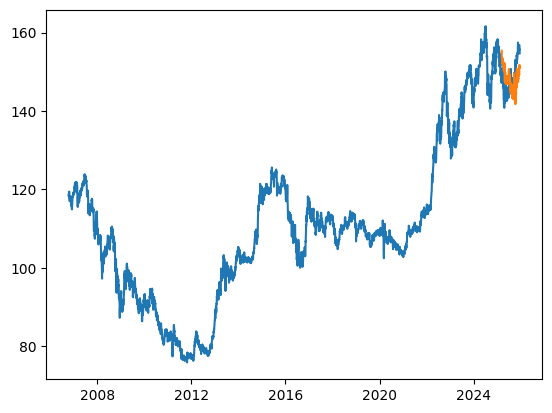

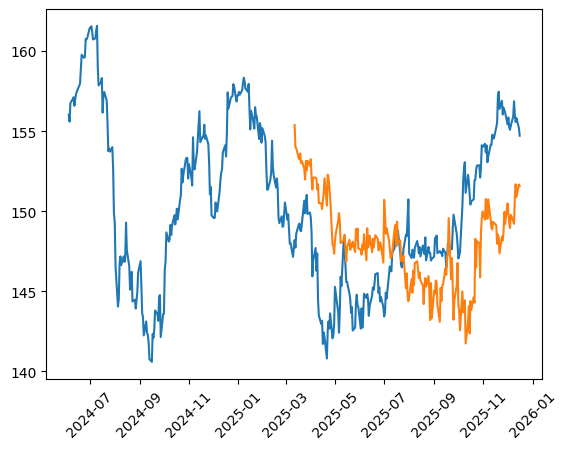

In [12]:
import matplotlib.pyplot as plt

# Flip data as it flips back again for some reason
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)

# Full data
plt.plot(usdYen_raw_data_dates, usdYen_raw_data)
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
plt.show()

# Zoom in on data
fig, ax = plt.subplots()
plt.plot(usdYen_raw_data_dates[:400], usdYen_raw_data[:400])
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
ax.tick_params("x", rotation=45)
plt.show()

## About the code

The Genetic Algorithm code is based on the code shown in the docs of the PyGAD library.

The timeseries data code is based on the code shown in the chapter of the book Deep Learning with Python.

## References

1- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries. Manning Publications.

2- PyGAD. pygad.kerasga Module. Retrieved from https://pygad.readthedocs.io/en/latest/kerasga.html#